이 노트북을 실행하는 데 필요한 라이브러리(표준 라이브러리 제외)
- torch
- numpy
- matplotlib

- 실습 기본 환경 설정


In [1]:

# 예제 실행 및 시각화를 위한 공통 라이브러리 로딩

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib 시각화에서 한글 폰트 사용 설정
common.set_korean_plot_env()

# 재현성 보장을 위한 시드 고정
#   여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 
#   독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.
#   또한 같은 환경에서도 GPU를 사용하는 경우, 일부 연산의 비결정적 성질로 인해 실행시마다 결과가 조금씩 달라질 수 있다.
SEED = 42
common.set_seed(SEED)

# 실습 환경에 맞는 하드웨어 가속기 장치 객체
device = common.get_device()

CUDA를 사용합니다.


# 10-3 트랜스포머의 변형 2, 디코더만 사용하는 트랜스포머

본 노트북은 본문 10-3절의 코드 예제와 관련 내용을 다룬다. 주요 내용은 다음과 같다.
- 크로스 어텐션 없이 인과 마스크만으로 동작하는 `OzWriterTransformer`
- 비중첩 분할로 만드는 디코더 전용 트랜스포머 학습용 데이터셋
- 탐욕 디코딩, 온도 샘플링, 빔 서치 세 가지 생성 전략
- 빔 서치의 후보 경로 추적([그림 10-6])

7-2절의 오즈의 소설가 모델을 디코더만 사용하는 트랜스포머로 다시 만든다.

> **이 노트북은 어휘 사전을 `Vocab` 클래스로 바꾼 판이다.** 본문 [코드 10-13]~[코드 10-15]가 `vocab.encode()`와 `vocab.decode()`를 호출하므로, 본문 코드를 고치지 않고 그대로 실행할 수 있도록 맞췄다. 딕셔너리를 쓰는 판은 `10-03_example_v2.ipynb`에 있다.


## 데이터 준비

- `data/wonderful_wizard_of_oz.txt`에서 본문(Chapter I 이후)을 추출하고 7-2절과 같은 방식으로 토큰화한다.

In [2]:
# 참고 - 오즈의 마법사 텍스트 로딩 (utf-8-sig + 앞 뒤의 문서 정보 영역 삭제)

from pathlib import Path
import re

raw = Path('../../data/wonderful_wizard_of_oz.txt').read_text(
    encoding='utf-8-sig',
)
match = re.search(r'\nChapter I\n', raw)
start = match.start() if match else raw.find('Chapter I')
end = raw.rfind('*** END OF THE PROJECT GUTENBERG')
if end == -1:
    end = raw.rfind('THE END')
text = raw[start:end].strip()

# 토큰화
normalized = text.lower()
normalized = re.sub(r'[^a-z\s,.!?\u2019\']', ' ', normalized)
tokens = re.findall(r"[a-z\u2019']+|[,.!?]", normalized)
tokens = [t.rstrip('\u2019') if not t.endswith("'") else t for t in tokens]
tokens = [t for t in tokens if t]
print(f'전체 토큰 수: {len(tokens):,}')
print(f'고유 토큰 수: {len(set(tokens)):,}')
print(f'처음 20 토큰: {tokens[:20]}')

전체 토큰 수: 44,299
고유 토큰 수: 2,902
처음 20 토큰: ['chapter', 'i', 'the', 'cyclone', 'dorothy', 'lived', 'in', 'the', 'midst', 'of', 'the', 'great', 'kansas', 'prairies', ',', 'with', 'uncle', 'henry', ',', 'who']


- 전체 텍스트를 길이 `SEQ_LENGTH + 1`의 부분 시퀀스로 겹치지 않게 잘라 각 샘플로 사용한다.
    - 7-2절의 슬라이딩 윈도우와 달리 샘플이 서로 겹치지 않으므로 같은 데이터로 더 많은 토큰을 학습할 수 있다.
    - 마지막 토큰을 자른 앞부분이 입력, 첫 토큰을 자른 뒷부분이 정답이 된다.

### 어휘 사전 클래스

- 본문 [코드 10-13]~[코드 10-15]의 생성 함수는 `vocab.encode()`와 `vocab.decode()`를 호출한다.
  9-1절 [코드 9-1]에서 정의한 `Vocab` 클래스를 그대로 사용한다.
- 9장에서는 글자 단위 토큰을 다뤘으므로 문자열의 리스트를 넘겼다.
  여기서는 단어 단위이므로 토큰 리스트를 한 겹 감싼 `[tokens]`를 넘긴다.
- 특수 토큰을 쓰지 않으므로 고유 번호는 0부터 매겨진다.
  정렬한 토큰에 0부터 번호를 붙이는 방식이라, 딕셔너리로 만든 어휘 사전과 매핑이 같다.

In [3]:
# 참고 - 어휘 사전 클래스(9-1절 [코드 9-1]과 같은 클래스)
#   본문 10-3절의 생성 함수는 vocab.encode()와 vocab.decode()를 호출하므로
#   딕셔너리가 아니라 이 클래스의 객체를 어휘 사전으로 사용한다.
class Vocab:
    def __init__(self, sequence_list, special_tokens):
        # 고유한 토큰의 집합(set)
        tokens = set()
        for sequence in sequence_list:
            tokens.update(sequence)
        # 어휘 사전: {토큰: 고유 번호} 형태의 딕셔너리
        self.vocab = {}
        # 특수 토큰을 어휘 사전에 먼저 추가
        self.vocab.update(special_tokens)
        idx_start = len(special_tokens)
        # 정렬한 토큰을 사용해 고유 번호 부여
        for i, token in enumerate(sorted(tokens)):
            self.vocab[token] = i + idx_start
        # 역방향 어휘 사전: {고유 번호: 토큰} 형태의 딕셔너리
        self.itos = {idx: token for token, idx in self.vocab.items()}

    # 인코딩: 문자열 -> 고유 번호 리스트
    def encode(self, input_sequence):
        return [self.vocab[token] for token in input_sequence]

    # 디코딩: 고유 번호 리스트 -> 토큰 리스트
    def decode(self, input_ids):
        return [self.itos[idx] for idx in input_ids]

    def __len__(self):
        return len(self.vocab)

In [4]:
######################################################################################
# 코드 10-12 - 비중첩 분할로 만드는 디코더 전용 트랜스포머 학습용 데이터셋 정의
######################################################################################

from torch.utils.data import Dataset, DataLoader
import torch

# 참고 - 어휘 사전(단어 단위): Vocab 클래스로 생성
vocab = Vocab([tokens], {})
vocab_size = len(vocab)

# 전체 토큰을 한 토큰씩 겹쳐 seq_length + 1 길이로 분할
#   : 겹치는 토큰은 앞 샘플 정답의 마지막 토큰이자 다음 샘플 입력의 첫 토큰
class OzTransformerDataset(Dataset):
    def __init__(self, token_idxs, seq_length):
        self.token_idxs = token_idxs
        self.seq_length = seq_length

    def __len__(self):
        # n개의 샘플에는 n * seq_length + 1개의 토큰이 필요: 1을 뺀 뒤 나눔
        return (len(self.token_idxs) - 1) // self.seq_length

    def __getitem__(self, idx):
        start = idx * self.seq_length
        end = start + self.seq_length + 1
        # chunk의 [0:seq_length]는 입력, [1:seq_length + 1]은 정답으로 사용
        chunk = self.token_idxs[start:end]
        return torch.tensor(chunk, dtype=torch.long)


SEQ_LENGTH = 32
token_idxs = vocab.encode(tokens)

# 전체 데이터를 8:2의 비율로 훈련 데이터셋과 검증 데이터셋으로 분할
split = int(len(token_idxs) * 0.8)
train_set = OzTransformerDataset(token_idxs[:split], SEQ_LENGTH)
valid_set = OzTransformerDataset(token_idxs[split:], SEQ_LENGTH)

BATCH_SIZE = 64
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'어휘 사전 크기: {vocab_size}')
print(f'훈련 / 검증 샘플 수: {len(train_set)} / {len(valid_set)}')
print(f'한 샘플 길이: {len(train_set[0])} (= SEQ_LENGTH + 1)')

어휘 사전 크기: 2902
훈련 / 검증 샘플 수: 1107 / 276
한 샘플 길이: 33 (= SEQ_LENGTH + 1)


## 학습 가능한 위치 인코딩

- 10-1절의 [코드 10-1]과 같다.

In [5]:
# 참고 - 학습 가능한 위치 인코딩(10-1, 10-2절과 동일)
import torch.nn as nn

# 참고 - 학습 가능한 위치 인코딩 (10-1 본문 [코드 10-1])
class PositionalEncoding(nn.Module):
    def __init__(self, max_length, d_model):
        super().__init__()
        self.position_embedding = nn.Embedding(max_length, d_model)
        self.activation = nn.Tanh()

    def forward(self, token_embedded):
        seq_length = token_embedded.size(1)
        positions = torch.arange(seq_length, device=token_embedded.device)
        pos_embedded = self.position_embedding(positions)
        return self.activation(token_embedded + pos_embedded)

## OzWriterTransformer 모델

- 크로스 어텐션이 필요 없으므로 디코더에도 `nn.TransformerEncoder`를 사용한다.
    - 같은 클래스를 쓰지만 인과 마스크를 적용하면 디코더로 동작한다([그림 10-5]).
- 모든 위치에서 다음 토큰을 동시에 예측하므로, 분류기는 모든 토큰의 출력을 받아 각 위치의 다음 토큰 로짓을 낸다.

In [6]:
######################################################################################
# 코드 10-11 - 디코더만 사용하는 트랜스포머 모델, OzWriterTransformer 클래스
######################################################################################

class OzWriterTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, ff_dim,
                 num_layers, max_length, dropout=0.1):
        super().__init__()
        # 모든 샘플의 길이가 같은 고정 길이 분할이므로 <pad>를 사용하지 않음
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(max_length, d_model)
        self.dropout = nn.Dropout(dropout)
        # 크로스 어텐션을 사용하지 않으면 디코더에도 nn.TransformerEncoder 클래스를 사용
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads, dim_feedforward=ff_dim, 
            dropout=dropout, batch_first=True
        )
        self.decoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers, enable_nested_tensor=False
        )
        # 다음 토큰 예측 분류기
        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, src):
        seq_length = src.size(1)
        # 인과 마스크: 미래 토큰을 차단해 단방향(디코더) 셀프 어텐션을 수행
        causal_mask = nn.Transformer.generate_square_subsequent_mask(
            seq_length, device=src.device
        )
        embedded = self.dropout(self.pos_encoding(self.embedding(src)))
        # is_causal=True - 마스크의 성격이 인과 마스크라는 사실을 전달
        output = self.decoder(embedded, mask=causal_mask, is_causal=True)
        # 모든 위치의 출력을 분류기에 통과시켜 다음 토큰 로짓 계산
        return self.fc(output)         # (B, seq_length, vocab_size)

## 모델의 학습

- 데이터셋이 반환한 `SEQ_LENGTH + 1` 길이의 청크에서 마지막 토큰을 자른 입력과, 첫 토큰을 자른 정답을 사용한다.
- 인과 마스크를 적용하므로 모든 위치의 다음 토큰을 한 번에 학습할 수 있다.

In [7]:
# 참고 - 학습 및 검증 함수
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size = 0.0, 0
    for chunk in loader:
        chunk = chunk.to(device)
        src = chunk[:, :-1]                     # (B, S)
        tgt = chunk[:, 1:]                      # (B, S)
        optimizer.zero_grad()
        logits = model(src)                     # (B, S, V)
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt.reshape(-1)
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_size = src.size(0)
        loss_sum += loss.item() * batch_size
        sample_size += batch_size
    return loss_sum / sample_size


@torch.no_grad()
def validation(model, loader, criterion, device):
    model.eval()
    loss_sum, sample_size = 0.0, 0
    for chunk in loader:
        chunk = chunk.to(device)
        src = chunk[:, :-1]
        tgt = chunk[:, 1:]
        logits = model(src)
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt.reshape(-1)
        )
        batch_size = src.size(0)
        loss_sum += loss.item() * batch_size
        sample_size += batch_size
    return loss_sum / sample_size


# 조기 종료를 적용하지 않은 학습 루프 함수(검증 손실만 계산)
def train_loop(model, train_loader, valid_loader,
                            criterion, optimizer, epochs, device):
    model.to(device)
    log = common.EpochLogger(
        epochs,
        columns=('훈련 손실', '검증 손실'),
        formats=('{:.4f}', '{:.4f}'),
    )
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        valid_loss = validation(model, valid_loader, criterion, device)
        log.row(epoch, train_loss, valid_loss)
    log.summary()
    return log

In [8]:
# 참고 - 모델 객체 생성과 학습

import torch.optim as optim

D_MODEL = 128
NUM_HEADS = 4
FF_DIM = 256
NUM_LAYERS = 2
MAX_LENGTH = 64
DROPOUT = 0.1
LR = 1e-3

model = OzWriterTransformer(
    vocab_size=vocab_size,
    d_model=D_MODEL, num_heads=NUM_HEADS, ff_dim=FF_DIM,
    num_layers=NUM_LAYERS, max_length=MAX_LENGTH, dropout=DROPOUT
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

 
EPOCHS = 100

# 모델 학습
log = train_loop(
    model, train_loader, valid_loader, criterion, optimizer,
    epochs=EPOCHS, device=device,
)

 에포크    훈련 손실    검증 손실     시간
  1/100       7.0416       6.0981     0:01


 10/100       4.6218       5.2171     0:03


 20/100       3.5990       5.2102     0:04


 30/100       2.8655       5.5403     0:06


 40/100       2.3476       5.9658     0:07


...

 60/100       1.7036       6.7620     0:11


 70/100       1.4887       7.1292     0:12


 80/100       1.3434       7.4379     0:14


 90/100       1.2192       7.7035     0:15


100/100       1.1104       7.9784     0:17
------------------------------------------
최적 14 에포크 · 검증 손실 5.1317 · 전체 학습 시간 0:17


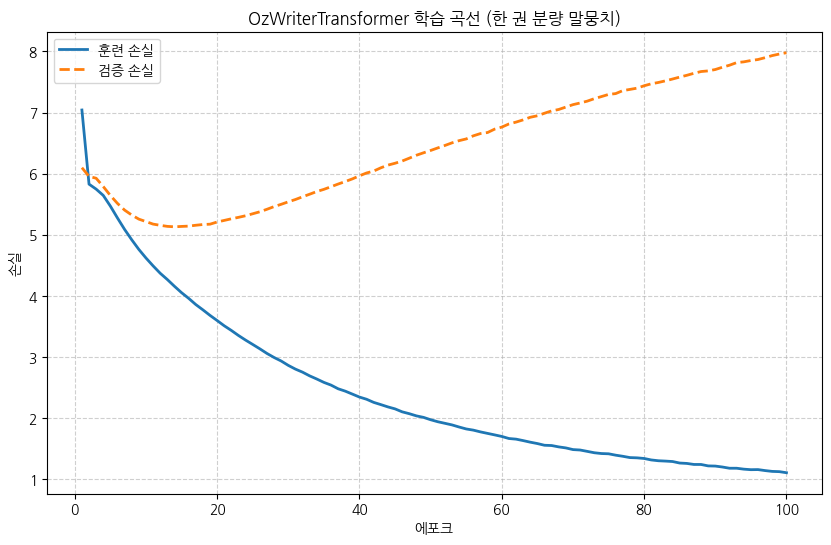

In [9]:
# 참고 - 학습 곡선 시각화
# 검증 손실이 20 에포크 부근에서 최저를 찍은 뒤 다시 상승한다.
log.plot(
    title='OzWriterTransformer 학습 곡선 (한 권 분량 말뭉치)',
)

- 학습 곡선에서 검증 손실이 초기에 떨어지다가 다시 꾸준히 상승하는 패턴이 보인다.
    - 한 권 분량의 작은 말뭉치에서 모델이 학습 데이터를 외워 가면서 검증 분포로부터 멀어지는 과적합이다.

## 탐욕 디코딩

- 매 단계 가장 높은 로짓의 토큰을 선택한다.
    - `<eos>`를 학습하지 않았으므로 정해진 개수만큼 생성한 뒤 멈춘다.

In [10]:
######################################################################################
# 코드 10-13 - 탐욕 디코딩을 적용한 생성 함수
######################################################################################

@torch.no_grad()
def generate_greedy(model, prompt, vocab, seq_length, max_new_words=10, device='cpu'):
    model.eval()
    words_in = prompt.lower().split()
    input_ids = vocab.encode(words_in)
    for _ in range(max_new_words):
        # 마중물 + 생성 토큰의 길이가 seq_length를 초과하면 앞부분을 잘라냄
        src = torch.tensor(input_ids[-seq_length:], dtype=torch.long)
        src = src.unsqueeze(0).to(device)
        logits = model(src)                             # (1, 입력 토큰 수, vocab_size)
        next_id = logits[0, -1, :].argmax().item()      # 마지막 위치의 최고 확률 토큰
        input_ids.append(next_id)
    return ' '.join(vocab.decode(input_ids))

for prompt in ['dorothy looked at', 'in the middle of']:
    print(f'=== 탐욕 디코딩 / 프롬프트: {prompt!r} ===')
    print(generate_greedy(
        model, prompt, vocab, SEQ_LENGTH,
        max_new_words=10, device=device
    ))
    print()

=== 탐욕 디코딩 / 프롬프트: 'dorothy looked at' ===


dorothy looked at her companions , and put them back to the little

=== 탐욕 디코딩 / 프롬프트: 'in the middle of' ===
in the middle of the water , looking very lonely and sad . what



## 온도 샘플링

- `argmax` 대신 `torch.multinomial`로 확률 분포에서 샘플링한다.
    - 로짓을 온도로 나눈 뒤 소프트맥스를 적용하므로, 온도가 낮으면 분포가 뾰족해져 탐욕 디코딩에 가까워지고 높으면 평평해져 다양해진다.
- 본문 [표 10-8]은 로짓이 5, 3, 2일 때 온도별 확률값을 보여 준다.

In [11]:
######################################################################################
# 코드 10-14 - 온도 샘플링을 적용한 생성 함수
######################################################################################

import torch.nn.functional as F

@torch.no_grad()
def generate_temperature(model, prompt, vocab, seq_length, max_new_words=10, 
                         temperature=1.0, device='cpu'):
    model.eval()
    words_in = prompt.lower().split()
    input_ids = vocab.encode(words_in)
    for _ in range(max_new_words):
        src = torch.tensor(
            input_ids[-seq_length:], dtype=torch.long
        ).unsqueeze(0).to(device)
        logits = model(src)
        # temperature: 온도 샘플링의 온도 하이퍼파라미터
        #              온도로 로짓을 나눠 확률 분포의 날카로움을 조절
        scaled_logits = logits[0, -1, :] / temperature
        probs = F.softmax(scaled_logits, dim=-1)
        # 확률 분포에서 샘플링(탐욕 디코딩과 달리 확률적으로 선택)
        next_id = torch.multinomial(probs, num_samples=1).item()
        input_ids.append(next_id)
    return ' '.join(vocab.decode(input_ids))


# 세 가지 온도값으로 동일 프롬프트 생성
prompt = 'in the middle of'
torch.manual_seed(SEED)
for temperature in [0.5, 1.0, 1.5]:
    print(f'=== 온도 {temperature} ===')
    for _ in range(4):
        print(generate_temperature(
            model, prompt, vocab, SEQ_LENGTH,
            max_new_words=10, temperature=temperature, device=device,
        ))
    print()

=== 온도 0.5 ===


in the middle of the water , looking very lonely and sad . what
in the middle of the water , looking very lonely and sad . what
in the middle of the water , looking very lonely and sad . what
in the middle of the water , looking very lonely and sad . what

=== 온도 1.0 ===
in the middle of the water , looking very lonely and sad . what
in the middle of the water , even the woodman sharpened his ears and
in the middle of the water , looking very lonely and sad . what
in the middle of the water , looking very lonely and sad . what

=== 온도 1.5 ===
in the middle of the great throne room but they all with wrinkles ,
in the middle of the water , seeing we think do at the door
in the middle of the water , looking very lonely and sad . after
in the middle of woodman himself room . that’s i want give a heart



## 빔 서치

- 매 단계 상위 `beam_width`개의 후보를 유지하며 경로를 탐색하고, 누적 로그 확률이 가장 높은 시퀀스를 반환한다.
    - 탐욕 디코딩은 매 단계 최선을 고르지만, 전체로 보면 더 좋은 경로를 놓칠 수 있다.

In [12]:
######################################################################################
# 코드 10-15 - 빔 서치를 적용한 생성 함수
######################################################################################

@torch.no_grad()
def generate_beam_search(model, prompt, vocab, seq_length,
                         max_new_words=10, beam_width=3,
                         device='cpu'):
    model.eval()
    words_in = prompt.lower().split()
    init_ids = vocab.encode(words_in)

    # 빔: (누적 로그 확률, 프롬프트 + 지금까지 생성한 토큰 인덱스 리스트) 
    beams = [(0.0, init_ids)]
    for _ in range(max_new_words):
        candidates = []
        for log_prob, ids in beams:
            src = torch.tensor(
                ids[-seq_length:], dtype=torch.long
            ).unsqueeze(0).to(device)
            logits = model(src)
            log_probs = F.log_softmax(logits[0, -1, :], dim=-1)
            # 상위 beam_width 개 후보 선택
            topk_log_probs, topk_ids = log_probs.topk(beam_width)
            for lp, nid in zip(
                topk_log_probs.tolist(), topk_ids.tolist()
            ):
                candidates.append((log_prob + lp, ids + [nid]))
        # 전체 후보 중 누적 로그 확률 상위 beam_width 개만 유지
        beams = sorted(candidates, key=lambda x: x[0], reverse=True)[:beam_width]
    # 누적 로그 확률이 가장 높은 시퀀스 반환
    best_ids = beams[0][1]
    return ' '.join(vocab.decode(best_ids))

# 세 가지 빔 너비로 비교
prompt = 'dorothy looked at'
for beam_width in [1, 3, 5]:
    print(f'=== 빔 너비 {beam_width} ===')
    print(generate_beam_search(
        model, prompt, vocab, SEQ_LENGTH,
        max_new_words=10, beam_width=beam_width, device=device,
    ))
    print()

=== 빔 너비 1 ===
dorothy looked at her companions , and put them back to the little

=== 빔 너비 3 ===
dorothy looked at her , and they walked along he sang tol de

=== 빔 너비 5 ===


dorothy looked at her , and they walked along he sang tol de



## 참고 - 빔 서치 탐색 트리 추적([그림 10-6])

- 빔 서치가 탐욕 디코딩과 갈라지는 순간을 눈으로 보기 위해, 단계마다 살아남은 빔과 가지치기로 탈락한 후보를 함께 추적한다.

In [13]:
# 참고 - 빔 서치 탐색 트리 추적([그림 10-6]의 예제)
def trace_beam_search(model, prompt, vocab, seq_length,
                      max_new_words=3, beam_width=3, device='cpu'):
    model.eval()
    init_ids = vocab.encode(prompt.lower().split())
    beams = [(0.0, init_ids)]
    with torch.no_grad():
        for step in range(max_new_words):
            candidates = []
            for log_prob, ids in beams:
                src = torch.tensor(
                    ids[-seq_length:], dtype=torch.long, device=device,
                ).unsqueeze(0)
                log_probs = F.log_softmax(model(src)[0, -1, :], dim=-1)
                topk_log_probs, topk_ids = log_probs.topk(beam_width)
                for lp, nid in zip(
                    topk_log_probs.tolist(), topk_ids.tolist(),
                ):
                    candidates.append((log_prob + lp, ids + [nid]))
            survivors = sorted(
                candidates, key=lambda x: x[0], reverse=True,
            )[:beam_width]
            survivor_ids = {id(c) for c in survivors}

            print(f'[{step + 1}단계] 후보 {len(candidates)}개 '
                  f'-> 상위 {beam_width}개 유지')
            for log_prob, ids in sorted(
                candidates, key=lambda x: x[0], reverse=True,
            ):
                mark = '유지' if any(
                    ids is s[1] for s in survivors
                ) else '탈락'
                text = ' '.join(vocab.decode(ids[len(init_ids):]))
                print(f'    {mark}  {log_prob:7.3f}  {text}')
            beams = survivors
            print()
    best_log_prob, best_ids = beams[0]
    print(f'최종 선택 (누적 로그 확률 {best_log_prob:.3f}): '
          f'{" ".join(vocab.decode(best_ids))}')
    return beams


# [그림 10-6]과 같은 케이스 - 2단계에서 탐욕 경로가 뒤집힌다
TRACE_PROMPT = 'each one of'
print(f'프롬프트: {TRACE_PROMPT!r}')
print(f'탐욕 디코딩: '
      f'{generate_greedy(model, TRACE_PROMPT, vocab, SEQ_LENGTH, 15, device)}')
print()
trace_beam_search(
    model, TRACE_PROMPT, vocab, SEQ_LENGTH,
    max_new_words=3, beam_width=3, device=device,
)
print()
print('--- 같은 프롬프트, 15 단어 생성 ---')
for width in (1, 3, 5):
    print(f'빔 너비 {width}: '
          f'{generate_beam_search(model, TRACE_PROMPT, vocab, SEQ_LENGTH, 15, width, device)}')

프롬프트: 'each one of'
탐욕 디코딩: each one of them to be alive . so they kept walking until they came to the road

[1단계] 후보 3개 -> 상위 3개 유지
    유지   -1.163  them
    유지   -1.471  you
    유지   -1.613  flesh

[2단계] 후보 9개 -> 상위 3개 유지
    유지   -1.476  you must
    유지   -2.012  them to
    유지   -2.266  flesh ,
    탈락   -2.538  flesh .
    탈락   -2.618  them ,
    탈락   -3.083  them at
    탈락   -5.840  flesh for
    탈락   -8.155  you may
    탈락   -9.145  you had

[3단계] 후보 9개 -> 상위 3개 유지
    유지   -1.492  you must enter
    유지   -3.028  flesh , and
    유지   -3.515  flesh , said
    탈락   -3.558  them to be
    탈락   -4.244  them to do
    탈락   -4.438  them to himself
    탈락   -4.753  flesh , for
    탈락   -6.049  you must be
    탈락   -7.804  you must sleep

최종 선택 (누적 로그 확률 -1.492): each one of you must enter

--- 같은 프롬프트, 15 단어 생성 ---
빔 너비 1: each one of them to be alive . so they kept walking until they came to the road
빔 너비 3: each one of you must enter his presence alone , and he will admit but one each

빔 너비 5: each one of you must enter his presence alone , and he will admit but one each day


## 정리

- 디코더만 사용하는 트랜스포머는 인과 마스크를 적용한 인코더 블록으로 구현할 수 있다. 크로스 어텐션이 없으므로 구조가 더 단순하다.
- 비중첩 분할은 슬라이딩 윈도우보다 샘플 수가 적지만 중복이 없어 학습 효율이 좋다.
- 생성 전략은 결과의 성격을 바꾼다.
    - 탐욕 디코딩은 안전하지만 단조롭고, 온도 샘플링은 다양하지만 불안정하며, 빔 서치는 누적 확률이 높은 경로를 찾는다.